In [1]:
!pip install pandas scikit-learn wordcloud matplotlib

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter

plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (윈도우)
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("naver_blog_ringle.csv")
print("원본 문서 수:", len(df))

df = df[df["ok"] == True].copy()
df["text"] = df["text"].fillna("").astype(str)
print("본문 추출 성공 문서 수:", len(df))

원본 문서 수: 240
본문 추출 성공 문서 수: 238


In [3]:
AD_HINTS = ["협찬", "제공받아", "원고료", "파트너스", "광고", "소정의", "지원받아"]

def is_ad(text: str) -> bool:
    t = text.replace(" ", "")
    return any(k.replace(" ", "") in t for k in AD_HINTS)

def normalize(text: str) -> str:
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text_norm"] = df["text"].apply(normalize)
df["is_ad2"] = df["text_norm"].apply(is_ad)

# 광고 제거
df_clean = df[df["is_ad2"] == False].copy()

# 너무 짧은 글 제거
df_clean = df_clean[df_clean["text_norm"].str.len() >= 120]

# 중복 제거
df_clean = df_clean.drop_duplicates(subset=["text_norm"]).reset_index(drop=True)

print("최종 분석 문서 수:", len(df_clean))
df_clean.head(3)

최종 분석 문서 수: 194


,query,url,api_title,api_desc,api_blogger,api_postdate,resolved_url,title,date,author,text,is_ad,ok,error,text_norm,is_ad2
0,링글 솔직 후기,https://blog.naver.com/toreng_747/224156340158,회화 '링글' 내돈내산 3년 사용 솔직 후기_링글 튜터 선생님 추천,링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님도 찾고 ...,토랭이 블로그,20260122,https://blog.naver.com/PostView.naver?blogId=t...,직장인 화상 영어 회화 '링글' 내돈내산 3년 사용 솔직 후기_링글 튜터 선생님 추천,2026. 1. 22. 22:00,토랭,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...,False,True,NaN,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...,False
1,링글 솔직 후기,https://blog.naver.com/economy_chaeni/22368042...,AI 영어 학습 앱 링글 솔직 후기 비즈니스 영어,"링글, AI 튜터, AI 영어, AI 영어회화 AI 영어 학습 앱 링글 기초적인 영...",ALL ABOUT DAILY,20241202,https://blog.naver.com/PostView.naver?blogId=e...,AI 영어 학습 앱 링글 솔직 후기 비즈니스 영어,2024. 12. 2. 23:02,채니,"링글, AI 튜터, AI 영어, AI 영어회화 ​ AI 영어 학습 앱 링글 기초적인...",False,True,NaN,"링글, AI 튜터, AI 영어, AI 영어회화 ​ AI 영어 학습 앱 링글 기초적인...",False
2,링글 솔직 후기,https://blog.naver.com/dolgoji324/223917116233,명문대 튜터와 1:1 화상영어? '링글' 이용 솔직 후기,"엄밀히 말하면 내돈내산은 아니지만, 솔직하게 후기 남기겠습니다 ㅎㅎ 링글은 명문대 ...",도란부부 일상,20250630,https://blog.naver.com/PostView.naver?blogId=d...,명문대 튜터와 1:1 화상영어? '링글' 이용 솔직 후기,2025. 6. 30. 21:52,도란부부,"안녕하세요, ​ 예전부터 영어공부에 관심이 많아서 직장다니면서도 화상영어, 전화영어...",False,True,NaN,"안녕하세요, ​ 예전부터 영어공부에 관심이 많아서 직장다니면서도 화상영어, 전화영어...",False


In [26]:
STOPWORDS = set("""
링글 영어 영어회화 회화 후기 사용 추천 수업 강의 선생님 튜터 원어민
오늘 이번 정말 진짜 그냥 너무 조금 약간 생각 느낌 때문
그리고 하지만 그래서 또한 또한 제가 저는 내가 우리는 너희
있다 있는 있어요 있습니다 하고 하는 했다 합니다 되다 된다
수업을 수업이 수업은 경우 위해 때문에 통해 관련
이것 저것 그런 이런 저런
많이 조금 약간 매우 가장 좀
to in of for with
""".split())

STOPWORDS.update("""
링글 링글은 링글을
나는 내가 우리는 저희
이렇게 저렇게 그런 이런 같다 있어서
com www http https
다양한 다른 원하는 전에
같아요 좋은 나의 저장인
많은 있고 대한 미리 the and you
""".split())

VERB_LIKE = ["하다", "되다", "있다", "없다", "같다"]

def tokenize(text):
    tokens = re.findall(r"[가-힣]{2,}|[A-Za-z]{2,}", text)
    tokens = [
        t for t in tokens
        if t not in STOPWORDS
        and not any(v in t for v in VERB_LIKE)
    ]
    return tokens

In [27]:
def normalize_tokens(text):
    text = re.sub(r"튜터(가|를|와|은|는)", "튜터", text)
    text = re.sub(r"영어(를|은|는)", "영어", text)
    text = re.sub(r"수업(을|이|은|는)", "수업", text)
    return text

df_clean["text_norm"] = df_clean["text_norm"].apply(normalize_tokens)

In [28]:
vectorizer = TfidfVectorizer(
    tokenizer=tokenize,
    lowercase=False,
    min_df=3,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df_clean["text_norm"])
terms = vectorizer.get_feature_names_out()

avg_tfidf = X.mean(axis=0).A1
top_idx = avg_tfidf.argsort()[::-1][:30]

keywords = pd.DataFrame({
    "keyword": terms[top_idx],
    "score": avg_tfidf[top_idx]
}).sort_values("score", ascending=False)

keywords

c:\Users\ljm16\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,keyword,score
0,AI,0.081151
1,화상영어,0.037425
2,피드백,0.019902
3,가격,0.019842
4,스피킹,0.019558
5,학습,0.018914
6,시간,0.018208
7,전화영어,0.018107
8,직장인,0.017936
9,바로,0.016492


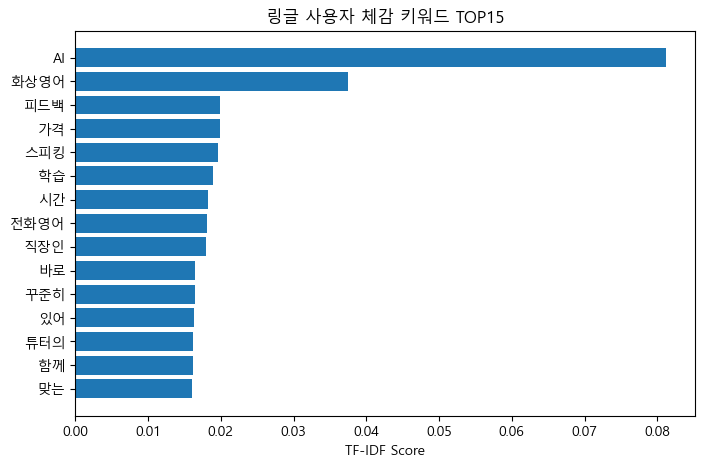

In [29]:
plt.figure(figsize=(8,5))
plt.barh(keywords["keyword"][:15][::-1], keywords["score"][:15][::-1])
plt.title("링글 사용자 체감 키워드 TOP15")
plt.xlabel("TF-IDF Score")
plt.show()

In [30]:
TOPICS = {
    "가격/가성비": ["가격", "비싸", "부담", "결제"],
    "피드백/교정": ["피드백", "교정", "첨삭"],
    "스피킹/학습": ["스피킹", "학습", "말하기"],
    "시간/직장인": ["시간", "직장인", "바로", "꾸준히"],
    "서비스 인식": ["AI", "화상영어"]
}

import re

def split_sentences(text):
    sents = re.split(r"[.!?\n\r]+", text)
    return [s.strip() for s in sents if len(s.strip()) >= 25]

rows = []

for _, row in df_clean.iterrows():
    text = row["text_norm"]
    sents = split_sentences(text)

    for topic, kws in TOPICS.items():
        matched = [s for s in sents if any(k in s for k in kws)]

        # 문서당 토픽별 최대 2문장만
        for s in matched[:2]:
            rows.append({
                "topic": topic,
                "sentence": s,
                "url": row["url"]
            })

topic_sent_df = pd.DataFrame(rows)
topic_sent_df.head()

,topic,sentence,url
0,가격/가성비,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...,https://blog.naver.com/toreng_747/224156340158
1,가격/가성비,​ 제가 좋아하는 튜터 스케쥴을 오픈하면 '튜터 우선 예약'을 통해서 내가 먼저 수...,https://blog.naver.com/toreng_747/224156340158
2,피드백/교정,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...,https://blog.naver.com/toreng_747/224156340158
3,스피킹/학습,"미국사람도 섞여있긴 한데, 주로 영국식 구사 튜터만 수업 듣고 있어요 ㅎㅎ 혹시 원...",https://blog.naver.com/toreng_747/224156340158
4,시간/직장인,​ 클릭하면 이렇게 자기소개 영상과 튜터의 키워드 자기소개 업무경험 취미 활동 수업...,https://blog.naver.com/toreng_747/224156340158


In [31]:
topic_sent_df["topic"].value_counts()

topic
시간/직장인    344
서비스 인식    311
피드백/교정    282
스피킹/학습    255
가격/가성비    251
Name: count, dtype: int64

In [32]:
for topic in TOPICS.keys():
    print(f"\n🔹 [{topic}] 대표 문장")
    display(
        topic_sent_df[topic_sent_df["topic"] == topic][["sentence"]]
        .head(5)
    )


🔹 [가격/가성비] 대표 문장


,sentence
0,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...
1,​ 제가 좋아하는 튜터 스케쥴을 오픈하면 '튜터 우선 예약'을 통해서 내가 먼저 수...
8,​ 쉐도잉 하는기분으로 하기에 딱인데 AI라서 부담도없는
9,심지어 초중급자도 쉽게 따라할 수 있도록 표현이 단계적으로 구성되어 있어서 부담 없...
32,"​ ​ 저는 추석 기간 할인이 들어가서 40분 x 24회 수업 938,000원에 결..."



🔹 [피드백/교정] 대표 문장


,sentence
2,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...
10,그리고 예시문이 나오는데 따라 읽고 듣는것만으로도 발음 교정도 되고 제 대화속도도 ...
11,바로바로 피드백을 받고 고칠 수 있다는것도 진짜 큰 장점
18,) ​ 1) 수업방식 설정 ​ 화상영어 진행할때 수강생의 선호도를 선택해요 : 자기...
19,"그리고 경우에 따라 추가 질문등을 하며, 제가 답변한 내용을 하나하나 놓치지 않고 ..."



🔹 [스피킹/학습] 대표 문장


,sentence
3,"미국사람도 섞여있긴 한데, 주로 영국식 구사 튜터만 수업 듣고 있어요 ㅎㅎ 혹시 원..."
12,"링글, AI 튜터, AI 영어, AI 영어회화 ​ AI 영어 학습 앱 링글 기초적인..."
13,"직장인을 위한 비즈니스 영어 특화 학습부터, 일상에서 쓰이는 표현까지"
20,튜터들과 자연스럽게 얘기하게되는 분위기 그리고 학습 교재나 진도에 얽매이지 않고 진...
27,(내돈내산 자발적 솔직 후기) 화상영어 업체를 찾고 있는 영어공부 학습자 동지들에게...



🔹 [시간/직장인] 대표 문장


,sentence
4,​ 클릭하면 이렇게 자기소개 영상과 튜터의 키워드 자기소개 업무경험 취미 활동 수업...
5,​ 근데 한국계 튜터 어쩃든 한국어 조금 이해는 하고 링글러가 뭘 원하는지 바로 알...
14,"직장인을 위한 비즈니스 영어 특화 학습부터, 일상에서 쓰이는 표현까지"
15,"​ 예를 들어, 회의에서 사용할 수 있는 표현이나, 제품 소개 시 유용한 문장들을 ..."
21,) ​ 1) 수업방식 설정 ​ 화상영어 진행할때 수강생의 선호도를 선택해요 : 자기...



🔹 [서비스 인식] 대표 문장


,sentence
6,신년 특가+1만 포인트+AI 멤버십 7일+무료 수업권 제공 www
7,"미국사람도 섞여있긴 한데, 주로 영국식 구사 튜터만 수업 듣고 있어요 ㅎㅎ 혹시 원..."
16,"링글, AI 튜터, AI 영어, AI 영어회화 ​ AI 영어 학습 앱 링글 기초적인..."
17,그런 저에게 AI 영어 회화 앱 링글(Ringle)이 큰 도움을 주었습니다
23,"안녕하세요, ​ 예전부터 영어공부에 관심이 많아서 직장다니면서도 화상영어, 전화영어..."


In [33]:
POS_WORDS = set("""
좋다 좋았 좋네요 만족 만족스러운 추천 추천해요 훌륭 훌륭한
도움 도움됨 도움이된다 유익 유용 유익한
빠르 빠르게 즉각 바로 정확 정확한 깔끔
편하 편리 편하게
늘었다 향상 성장 좋아짐 효과 효과적
친절 친절한 자연스럽다 안정적
""".split())

NEG_WORDS = set("""
비싸 비쌈 부담 비효율 아깝 아쉬움 아쉽다
힘들 어렵 불편 불만 답답
느리 느려 버그 오류 문제
별로 실망 후회
취소 환불 안됨 안돼 안되
""".split())

# 부정 표현(negation) 처리용
NEGATORS = ["안", "못", "없", "아니", "별로"]

In [34]:
POS_WORDS = set("""
좋다 좋았 좋네요 만족 만족스러운 추천 추천해요 훌륭 훌륭한
도움 도움됨 도움이된다 유익 유용 유익한
빠르 빠르게 즉각 바로 정확 정확한 깔끔
편하 편리 편하게
늘었다 향상 성장 좋아짐 효과 효과적
친절 친절한 자연스럽다 안정적
""".split())

NEG_WORDS = set("""
비싸 비쌈 부담 비효율 아깝 아쉬움 아쉽다
힘들 어렵 불편 불만 답답
느리 느려 버그 오류 문제
별로 실망 후회
취소 환불 안됨 안돼 안되
""".split())

# 부정 표현(negation) 처리용
NEGATORS = ["안", "못", "없", "아니", "별로"]

In [35]:
import re

def sent_tokens(s: str):
    # 한글/영문만 2글자 이상(필요하면 한글만으로 바꿔도 됨)
    return re.findall(r"[가-힣]{2,}|[A-Za-z]{2,}", s)

def sentiment_score(sentence: str):
    toks = sent_tokens(sentence)
    pos = 0
    neg = 0
    
    # 간단한 부정어 처리: "안좋다" 같이 붙는 경우/바로 앞 토큰이 부정어인 경우를 고려
    for i, t in enumerate(toks):
        t_clean = t.lower()
        
        # 부정어가 포함된 형태(예: 안좋다) -> 긍정 단어면 부정으로, 부정 단어면 긍정으로 뒤집기
        has_negator = any(t_clean.startswith(n) for n in NEGATORS)  # 안좋다 같은 케이스
        prev_is_negator = (i > 0 and any(toks[i-1].startswith(n) for n in NEGATORS))  # "안" "좋다"
        flip = has_negator or prev_is_negator
        
        base = t  # 한국어는 그대로 비교(부분일치 전략으로 처리)
        
        # 부분일치: "좋았", "좋네요", "빠르다" 같은 변화형을 잡기 위해 startswith 사용
        is_pos = any(base.startswith(w) for w in POS_WORDS)
        is_neg = any(base.startswith(w) for w in NEG_WORDS)
        
        if is_pos:
            if flip: neg += 1
            else: pos += 1
        elif is_neg:
            if flip: pos += 1
            else: neg += 1
    
    score = pos - neg
    return score, pos, neg

In [36]:
import re

def sent_tokens(s: str):
    # 한글/영문만 2글자 이상(필요하면 한글만으로 바꿔도 됨)
    return re.findall(r"[가-힣]{2,}|[A-Za-z]{2,}", s)

def sentiment_score(sentence: str):
    toks = sent_tokens(sentence)
    pos = 0
    neg = 0
    
    # 간단한 부정어 처리: "안좋다" 같이 붙는 경우/바로 앞 토큰이 부정어인 경우를 고려
    for i, t in enumerate(toks):
        t_clean = t.lower()
        
        # 부정어가 포함된 형태(예: 안좋다) -> 긍정 단어면 부정으로, 부정 단어면 긍정으로 뒤집기
        has_negator = any(t_clean.startswith(n) for n in NEGATORS)  # 안좋다 같은 케이스
        prev_is_negator = (i > 0 and any(toks[i-1].startswith(n) for n in NEGATORS))  # "안" "좋다"
        flip = has_negator or prev_is_negator
        
        base = t  # 한국어는 그대로 비교(부분일치 전략으로 처리)
        
        # 부분일치: "좋았", "좋네요", "빠르다" 같은 변화형을 잡기 위해 startswith 사용
        is_pos = any(base.startswith(w) for w in POS_WORDS)
        is_neg = any(base.startswith(w) for w in NEG_WORDS)
        
        if is_pos:
            if flip: neg += 1
            else: pos += 1
        elif is_neg:
            if flip: pos += 1
            else: neg += 1
    
    score = pos - neg
    return score, pos, neg

In [37]:
topic_sent_df = topic_sent_df.copy()

scores = topic_sent_df["sentence"].apply(lambda s: sentiment_score(s))
topic_sent_df["sent_score"] = scores.apply(lambda x: x[0])
topic_sent_df["pos_cnt"] = scores.apply(lambda x: x[1])
topic_sent_df["neg_cnt"] = scores.apply(lambda x: x[2])

topic_sent_df.head(10)

,topic,sentence,url,sent_score,pos_cnt,neg_cnt
0,가격/가성비,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...,https://blog.naver.com/toreng_747/224156340158,0,0,0
1,가격/가성비,​ 제가 좋아하는 튜터 스케쥴을 오픈하면 '튜터 우선 예약'을 통해서 내가 먼저 수...,https://blog.naver.com/toreng_747/224156340158,0,1,1
2,피드백/교정,이번에도 링글에서 3년 차 이용하면서 영어공부가 잘 되고 마음 잘 맞는 회화 선생님...,https://blog.naver.com/toreng_747/224156340158,0,0,0
3,스피킹/학습,"미국사람도 섞여있긴 한데, 주로 영국식 구사 튜터만 수업 듣고 있어요 ㅎㅎ 혹시 원...",https://blog.naver.com/toreng_747/224156340158,0,0,0
4,시간/직장인,​ 클릭하면 이렇게 자기소개 영상과 튜터의 키워드 자기소개 업무경험 취미 활동 수업...,https://blog.naver.com/toreng_747/224156340158,0,0,0
5,시간/직장인,​ 근데 한국계 튜터 어쩃든 한국어 조금 이해는 하고 링글러가 뭘 원하는지 바로 알...,https://blog.naver.com/toreng_747/224156340158,1,1,0
6,서비스 인식,신년 특가+1만 포인트+AI 멤버십 7일+무료 수업권 제공 www,https://blog.naver.com/toreng_747/224156340158,0,0,0
7,서비스 인식,"미국사람도 섞여있긴 한데, 주로 영국식 구사 튜터만 수업 듣고 있어요 ㅎㅎ 혹시 원...",https://blog.naver.com/toreng_747/224156340158,0,0,0
8,가격/가성비,​ 쉐도잉 하는기분으로 하기에 딱인데 AI라서 부담도없는,https://blog.naver.com/economy_chaeni/22368042...,-1,0,1
9,가격/가성비,심지어 초중급자도 쉽게 따라할 수 있도록 표현이 단계적으로 구성되어 있어서 부담 없...,https://blog.naver.com/economy_chaeni/22368042...,-1,0,1


In [38]:
summary = (
    topic_sent_df
    .groupby("topic")
    .agg(
        n=("sentence", "count"),
        avg_score=("sent_score", "mean"),
        pos_ratio=("sent_score", lambda x: (x > 0).mean()),
        neg_ratio=("sent_score", lambda x: (x < 0).mean()),
        neutral_ratio=("sent_score", lambda x: (x == 0).mean()),
        avg_pos=("pos_cnt", "mean"),
        avg_neg=("neg_cnt", "mean"),
    )
    .sort_values("avg_score", ascending=False)
)

summary

,n,avg_score,pos_ratio,neg_ratio,neutral_ratio,avg_pos,avg_neg
topic,,,,,,,
피드백/교정,282,0.358156,0.280142,0.046099,0.673759,0.450355,0.092199
스피킹/학습,255,0.349020,0.235294,0.031373,0.733333,0.415686,0.066667
시간/직장인,344,0.273256,0.287791,0.063953,0.648256,0.392442,0.119186
서비스 인식,311,0.209003,0.199357,0.022508,0.778135,0.270096,0.061093
가격/가성비,251,-0.163347,0.155378,0.322709,0.521912,0.310757,0.474104


In [ ]:
def show_examples(topic, k=5):
    sub = topic_sent_df[topic_sent_df["topic"] == topic].copy()
    print(f"\n=== [{topic}] 긍정 상위 {k} ===")
    display(sub.sort_values("sent_score", ascending=False)[["sent_score","sentence","url"]].head(k))
    
    print(f"\n=== [{topic}] 부정 상위 {k} ===")
    display(sub.sort_values("sent_score", ascending=True)[["sent_score","sentence","url"]].head(k))

for t in topic_sent_df["topic"].unique():
    show_examples(t, k=3)


=== [가격/가성비] 긍정 상위 3 ===


,sent_score,sentence,url
648,4,com ​ ​ ​ ​ 언제 어디서나 링글 어플을 통해 AI 튜터 기능 으로 회화 공...,https://blog.naver.com/24-08-30/223658014306
349,3,예를 들면 이런 거죵 1) 비즈니스 영어 난 대학 때도 계속 영어 사용해왔고 (전공...,https://blog.naver.com/lalala6868/223046880032
1215,2,🔽 🔽 🔽 더 자세한 내용은 ​ 아래 링크 를 클릭 하세요 🔽 🔽 🔽 대구시 원어민...,https://blog.naver.com/bqeqrcwcx593/223600864007



=== [가격/가성비] 부정 상위 3 ===


,sent_score,sentence,url
690,-2,"​ 매일 원어민 수업 하면 조금 부담스러울 수 있는데, AI와 연습하는 건 전혀 부...",https://blog.naver.com/mungzae/223595266713
941,-2,내가 생각해도 영어로 말하는것 자체가 부담이었던 초반과 달리 현재 나는 영어로 듣고...,https://blog.naver.com/project327/224036367220
1042,-2,튜터 만나서 내 스타일에 맞춰달라고 하는 것도 다 시간이고 부담인데 그 부담을 확 ...,https://blog.naver.com/yrc0423/223519645628



=== [피드백/교정] 긍정 상위 3 ===


...

,sent_score,sentence,url
805,-2,2만원이 넘어요 ㅠ ​ 눈물을 머금고 일어나서 수업 들었는데 새로 들은 튜터 너무 ...,https://blog.naver.com/sr35_ydk/223289973882
998,-2,수업 예약 시스템의 비효율성 링글은 튜터 수업 시간을 선택하는 시스템을 운영하고 있...,https://blog.naver.com/sgdfgdfgdrg226/22361852...
897,-2,"하지만 시간을 맞추기도 힘들고, 가격적인 부담이 있고, 결정적으로 1:n 방식의 회...",https://blog.naver.com/eng1588/222979201238



=== [서비스 인식] 긍정 상위 3 ===


,sent_score,sentence,url
654,4,com ​ ​ ​ ​ 언제 어디서나 링글 어플을 통해 AI 튜터 기능 으로 회화 공...,https://blog.naver.com/24-08-30/223658014306
325,2,화상영어 돈만 내고 안하기 쉬운데 왠만한 학원보다 효과는 좋다고 생각함…,https://blog.naver.com/rla3wl4tn2/223262801791
974,2,드디어 수업 들어보고 링글 후기 남길 수 있게 됐네요 결론적으로 링글 가격도 합리적...,https://blog.naver.com/eve14eve/223595257964



=== [서비스 인식] 부정 상위 3 ===


,sent_score,sentence,url
492,-1,"​ 회사에서 지원해줘서 한달동안 링글 화상영어 도 해보았지만, 선생님 자기소개 영상...",https://blog.naver.com/dino_stori/224131700453
423,-1,"'라는 마음으로 만끽하도록 살짝 방치하고 있긴 한데요, 이런 시기에 영어스피킹 실력...",https://blog.naver.com/chaos1329/223254641435
88,-1,"화상영어 중에선 정말 탑급으로 비싸고, 결제할 때 손이 덜덜 떨리는 수준… ​ 그리...",https://blog.naver.com/gradually-/223741166634


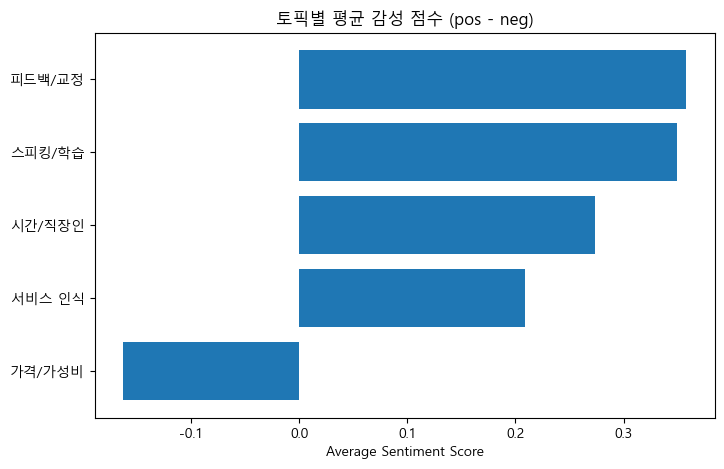

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(summary.index[::-1], summary["avg_score"][::-1])
plt.title("토픽별 평균 감성 점수 (pos - neg)")
plt.xlabel("Average Sentiment Score")
plt.show()